In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

print("Libraries imported successfully!")
print("SHAP version:", shap.__version__)

Libraries imported successfully!
SHAP version: 0.52.0


In [2]:
MODEL_PATH = "../models/supervised/xgboost.joblib"

xgb_model = joblib.load(MODEL_PATH)

print("XGBoost model loaded successfully!")
print("Model type:", type(xgb_model))

XGBoost model loaded successfully!
Model type: <class 'xgboost.sklearn.XGBClassifier'>


In [3]:
DATA_PATH = "../data/processed/cleaned_data.csv"
PREPROCESSING_DIR = "../models/preprocessing"

df = pd.read_csv(DATA_PATH)

label_encoder = joblib.load(
    os.path.join(PREPROCESSING_DIR, "label_encoder.joblib")
)

print("Dataset and label encoder loaded successfully!")
print("Dataset shape:", df.shape)
print("Number of classes:", len(label_encoder.classes_))

Dataset and label encoder loaded successfully!
Dataset shape: (2830743, 79)
Number of classes: 15


In [4]:
FEATURES = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Fwd URG Flags",
    "Bwd Packets/s",
    "Min Packet Length",
    "Max Packet Length",
    "Packet Length Mean",
    "Packet Length Variance",
    "FIN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward",
    "min_seg_size_forward",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Std"
]

X = df[FEATURES]
y = label_encoder.transform(df["Label"])

print("Exact Phase 4 feature matrix recreated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(FEATURES))

Exact Phase 4 feature matrix recreated successfully!
X shape: (2830743, 45)
y shape: (2830743,)
Number of features: 45


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Exact Phase 6 split recreated successfully!")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Exact Phase 6 split recreated successfully!
X_train: (1981520, 45)
X_val: (424611, 45)
X_test: (424612, 45)


In [6]:
SHAP_SAMPLE_SIZE = 5000

X_shap = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("SHAP sample created successfully!")
print("SHAP sample shape:", X_shap.shape)

SHAP sample created successfully!
SHAP sample shape: (5000, 45)


In [7]:
explainer = shap.TreeExplainer(xgb_model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [8]:
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully!")
print("SHAP values type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of first class:", shap_values[0].shape)
else:
    print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (5000, 45, 15)


In [9]:
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Mean |SHAP|": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
).reset_index(drop=True)

print("Overall SHAP feature importance calculated successfully!")
print()
print(feature_importance.head(15).to_string(index=False))

Overall SHAP feature importance calculated successfully!

                    Feature  Mean |SHAP|
           Destination Port     0.874554
    Init_Win_bytes_backward     0.366540
       min_seg_size_forward     0.326389
     Init_Win_bytes_forward     0.302264
                Fwd IAT Min     0.273602
               Flow IAT Min     0.270947
              Bwd Packets/s     0.266165
               Fwd IAT Mean     0.197195
Total Length of Fwd Packets     0.194404
      Fwd Packet Length Max     0.194323
         Packet Length Mean     0.152903
               Flow Bytes/s     0.140043
      Bwd Packet Length Max     0.126720
              Flow Duration     0.120153
     Packet Length Variance     0.119483


In [10]:
SHAP_RESULTS_PATH = "../reports/model_results/shap_feature_importance.csv"

feature_importance.to_csv(
    SHAP_RESULTS_PATH,
    index=False
)

print("SHAP feature importance saved successfully!")
print("Saved to:", SHAP_RESULTS_PATH)

SHAP feature importance saved successfully!
Saved to: ../reports/model_results/shap_feature_importance.csv


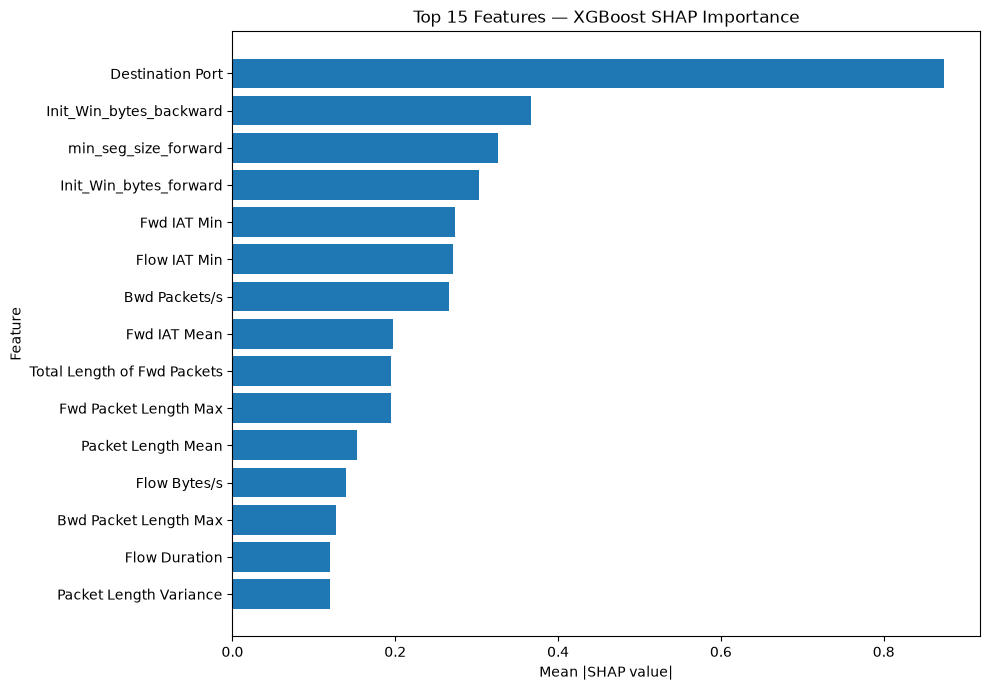

SHAP feature-importance plot saved successfully!
Saved to: ../reports/figures/shap_feature_importance.png


In [11]:
TOP_N = 15

top_features = feature_importance.head(TOP_N).sort_values(
    "Mean |SHAP|",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean |SHAP|"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 15 Features — XGBoost SHAP Importance")

plt.tight_layout()

SHAP_FIGURE_PATH = "../reports/figures/shap_feature_importance.png"

plt.savefig(
    SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP feature-importance plot saved successfully!")
print("Saved to:", SHAP_FIGURE_PATH)

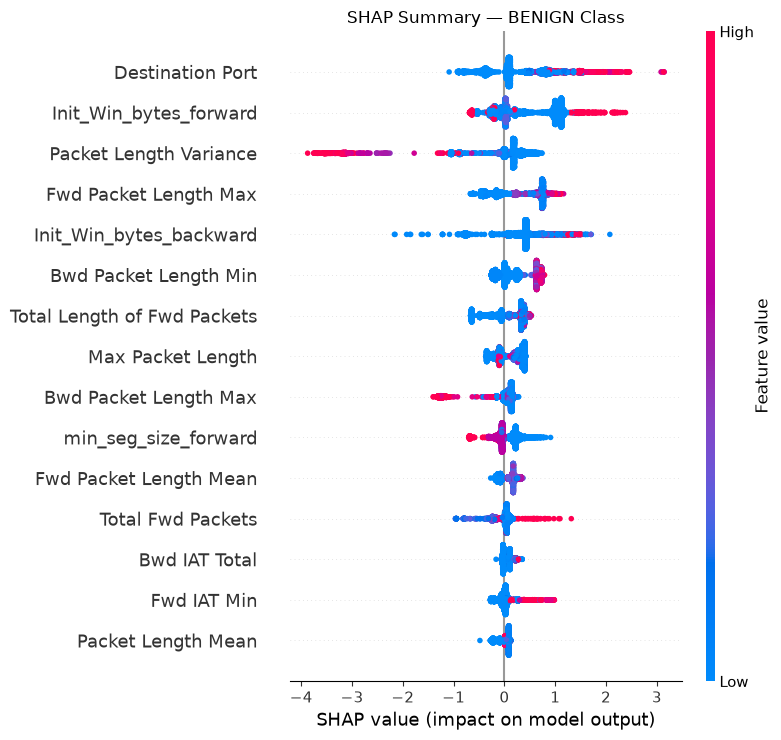

BENIGN SHAP summary plot saved successfully!
Saved to: ../reports/figures/shap_summary_benign.png


In [12]:
BENIGN_CLASS = 0

shap.summary_plot(
    shap_values[:, :, BENIGN_CLASS],
    X_shap,
    feature_names=FEATURES,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — BENIGN Class")

plt.tight_layout()

BENIGN_SHAP_FIGURE_PATH = "../reports/figures/shap_summary_benign.png"

plt.savefig(
    BENIGN_SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("BENIGN SHAP summary plot saved successfully!")
print("Saved to:", BENIGN_SHAP_FIGURE_PATH)

DDoS class index: 2


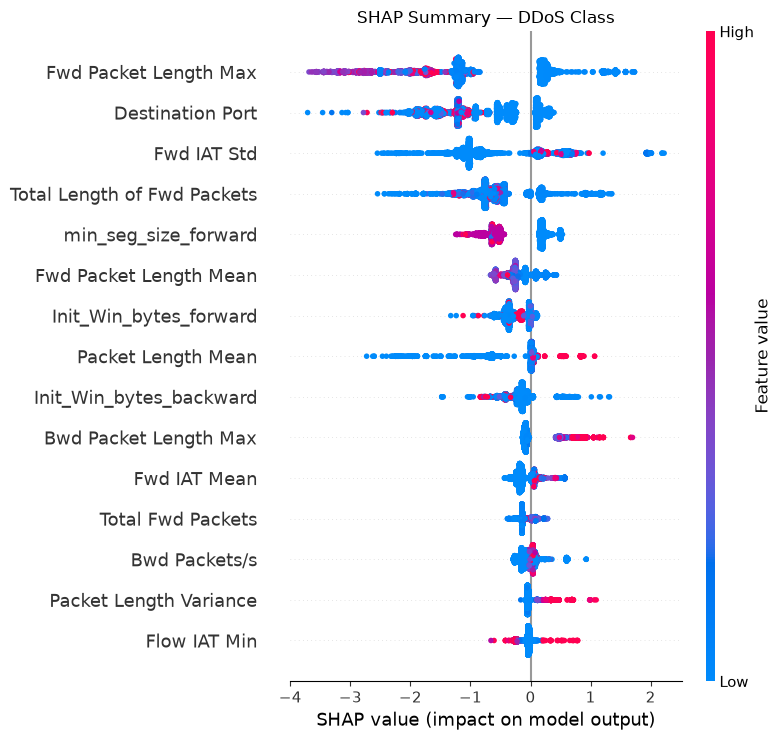

DDoS SHAP summary plot saved successfully!
Saved to: ../reports/figures/shap_summary_ddos.png


In [13]:
DDOS_CLASS = label_encoder.transform(["DDoS"])[0]

print("DDoS class index:", DDOS_CLASS)

shap.summary_plot(
    shap_values[:, :, DDOS_CLASS],
    X_shap,
    feature_names=FEATURES,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — DDoS Class")

plt.tight_layout()

DDOS_SHAP_FIGURE_PATH = "../reports/figures/shap_summary_ddos.png"

plt.savefig(
    DDOS_SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("DDoS SHAP summary plot saved successfully!")
print("Saved to:", DDOS_SHAP_FIGURE_PATH)

In [14]:
TOP_FEATURES_PATH = "../reports/model_results/shap_top15_features.csv"

top_features_report = feature_importance.head(15).copy()

top_features_report.insert(
    0,
    "Rank",
    range(1, len(top_features_report) + 1)
)

top_features_report.to_csv(
    TOP_FEATURES_PATH,
    index=False
)

print("Top 15 SHAP features saved successfully!")
print("Saved to:", TOP_FEATURES_PATH)
print()
print(top_features_report.to_string(index=False))

Top 15 SHAP features saved successfully!
Saved to: ../reports/model_results/shap_top15_features.csv

 Rank                     Feature  Mean |SHAP|
    1            Destination Port     0.874554
    2     Init_Win_bytes_backward     0.366540
    3        min_seg_size_forward     0.326389
    4      Init_Win_bytes_forward     0.302264
    5                 Fwd IAT Min     0.273602
    6                Flow IAT Min     0.270947
    7               Bwd Packets/s     0.266165
    8                Fwd IAT Mean     0.197195
    9 Total Length of Fwd Packets     0.194404
   10       Fwd Packet Length Max     0.194323
   11          Packet Length Mean     0.152903
   12                Flow Bytes/s     0.140043
   13       Bwd Packet Length Max     0.126720
   14               Flow Duration     0.120153
   15      Packet Length Variance     0.119483


In [15]:
class_shap_importance = []

for class_index, class_name in enumerate(label_encoder.classes_):
    class_mean_abs = np.abs(
        shap_values[:, :, class_index]
    ).mean(axis=0)

    class_importance = pd.DataFrame({
        "Feature": FEATURES,
        "Mean |SHAP|": class_mean_abs
    })

    class_importance = class_importance.sort_values(
        "Mean |SHAP|",
        ascending=False
    ).head(10)

    class_importance.insert(
        0,
        "Class",
        class_name
    )

    class_shap_importance.append(class_importance)

class_shap_importance = pd.concat(
    class_shap_importance,
    ignore_index=True
)

CLASS_SHAP_PATH = "../reports/model_results/shap_class_feature_importance.csv"

class_shap_importance.to_csv(
    CLASS_SHAP_PATH,
    index=False
)

print("Class-level SHAP importance calculated successfully!")
print("Saved to:", CLASS_SHAP_PATH)
print()
print(class_shap_importance.head(20).to_string(index=False))

Class-level SHAP importance calculated successfully!
Saved to: ../reports/model_results/shap_class_feature_importance.csv

 Class                     Feature  Mean |SHAP|
BENIGN            Destination Port     0.557488
BENIGN      Init_Win_bytes_forward     0.545694
BENIGN      Packet Length Variance     0.534970
BENIGN       Fwd Packet Length Max     0.524415
BENIGN     Init_Win_bytes_backward     0.482834
BENIGN       Bwd Packet Length Min     0.338753
BENIGN Total Length of Fwd Packets     0.308274
BENIGN           Max Packet Length     0.239542
BENIGN       Bwd Packet Length Max     0.199052
BENIGN        min_seg_size_forward     0.184591
   Bot      Init_Win_bytes_forward     1.402782
   Bot            Destination Port     0.889227
   Bot                 Bwd IAT Min     0.701765
   Bot     Init_Win_bytes_backward     0.595503
   Bot               Flow IAT Mean     0.327946
   Bot                Fwd IAT Mean     0.318733
   Bot                Flow IAT Max     0.275942
   Bot       

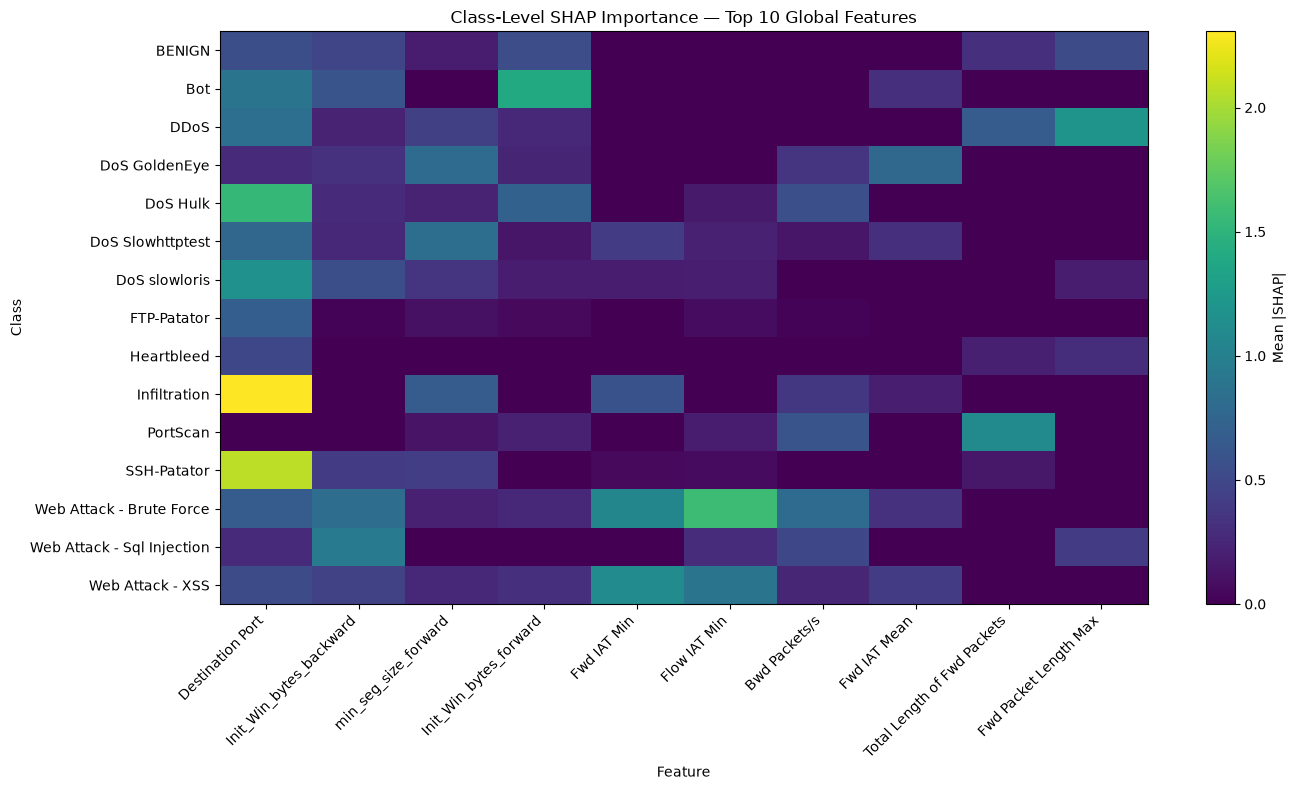

Class-level SHAP heatmap saved successfully!
Saved to: ../reports/figures/shap_class_feature_heatmap.png


In [16]:
# Select the top 10 globally important features
TOP_GLOBAL_FEATURES = feature_importance.head(10)["Feature"].tolist()

# Create class × feature importance matrix
class_feature_matrix = (
    class_shap_importance[
        class_shap_importance["Feature"].isin(TOP_GLOBAL_FEATURES)
    ]
    .pivot(
        index="Class",
        columns="Feature",
        values="Mean |SHAP|"
    )
    .fillna(0)
)

# Keep the global feature order
class_feature_matrix = class_feature_matrix.reindex(
    columns=TOP_GLOBAL_FEATURES
)

plt.figure(figsize=(14, 8))

plt.imshow(
    class_feature_matrix.values,
    aspect="auto"
)

plt.colorbar(label="Mean |SHAP|")

plt.xticks(
    range(len(class_feature_matrix.columns)),
    class_feature_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_feature_matrix.index)),
    class_feature_matrix.index
)

plt.xlabel("Feature")
plt.ylabel("Class")
plt.title("Class-Level SHAP Importance — Top 10 Global Features")

plt.tight_layout()

CLASS_SHAP_FIGURE_PATH = (
    "../reports/figures/shap_class_feature_heatmap.png"
)

plt.savefig(
    CLASS_SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class-level SHAP heatmap saved successfully!")
print("Saved to:", CLASS_SHAP_FIGURE_PATH)

In [17]:
CLASS_SHAP_MATRIX_PATH = (
    "../reports/model_results/shap_class_feature_matrix.csv"
)

class_feature_matrix.to_csv(
    CLASS_SHAP_MATRIX_PATH
)

print("Class-level SHAP matrix saved successfully!")
print("Saved to:", CLASS_SHAP_MATRIX_PATH)

Class-level SHAP matrix saved successfully!
Saved to: ../reports/model_results/shap_class_feature_matrix.csv


In [18]:
print("=" * 70)
print("PHASE 7 — SHAP EXPLAINABILITY COMPLETED")
print("=" * 70)

print("\nModel:")
print("XGBoost")

print("\nSHAP Analysis:")
print(f"Samples analyzed: {len(X_shap):,}")
print(f"Number of features: {len(FEATURES)}")
print(f"Number of classes: {len(label_encoder.classes_)}")

print("\nTop 10 Global Features:")
print(
    feature_importance.head(10)[
        ["Feature", "Mean |SHAP|"]
    ].to_string(index=False)
)

print("\nKey Explainability Findings:")
print("- Destination Port had the highest overall mean absolute SHAP value.")
print("- TCP window, packet-size, rate, and timing features were also important.")
print("- Feature importance varied across individual NIDS classes.")
print("- BENIGN and DDoS predictions showed different feature contribution patterns.")
print("- Web Attack classes showed overlapping feature importance patterns.")
print("- Minority classes should be interpreted carefully because they contain very few samples.")

print("\nSaved SHAP outputs under:")
print("../reports/figures/")
print("../reports/model_results/")

print("\nPhase 7 completed successfully!")

PHASE 7 — SHAP EXPLAINABILITY COMPLETED

Model:
XGBoost

SHAP Analysis:
Samples analyzed: 5,000
Number of features: 45
Number of classes: 15

Top 10 Global Features:
                    Feature  Mean |SHAP|
           Destination Port     0.874554
    Init_Win_bytes_backward     0.366540
       min_seg_size_forward     0.326389
     Init_Win_bytes_forward     0.302264
                Fwd IAT Min     0.273602
               Flow IAT Min     0.270947
              Bwd Packets/s     0.266165
               Fwd IAT Mean     0.197195
Total Length of Fwd Packets     0.194404
      Fwd Packet Length Max     0.194323

Key Explainability Findings:
- Destination Port had the highest overall mean absolute SHAP value.
- TCP window, packet-size, rate, and timing features were also important.
- Feature importance varied across individual NIDS classes.
- BENIGN and DDoS predictions showed different feature contribution patterns.
- Web Attack classes showed overlapping feature importance patterns.
- M